# Data Science Assignment: Customer Churn Prediction

## Business Problem

A telecommunications company wants to identify customers likely to churn
so its retention team can engage them proactively. This notebook develops
a reusable Decision Tree classification pipeline from the provided IBM
Telco Customer Churn dataset. The target is `Churn` (`No = 0`, `Yes = 1`).

## Execution instructions

| File | Location inside the project |
|---|---|
| Notebook | `notebooks/customer_churn.ipynb` |
| Reusable transformer | `src/preprocessing.py` |
| Dataset | `data/TelcoCustomerChurn.csv` |
| Data dictionary | `data/TelcoCustomerChurn - Data Dictionary.csv` |

Use the project's Python environment with pandas, NumPy, Scikit-learn,
Matplotlib, Seaborn, joblib, and ipykernel installed. Restart the kernel
after replacing the transformer, run all cells in order, then save the
notebook with outputs retained. The search runs with one worker to limit
memory use and may take several minutes. Runtime versions are printed below.

## 1. Data Understanding & Preparation

Data preparation establishes what each record means, identifies quality
issues, and defines transformations needed before modelling. Every
preparation instruction in the PDF is addressed separately below.

### 1.0 Load and investigate the dataset

**Definition:** load the supplied customer records into a table and inspect
a sample before analysis.

**Method and evidence:** `pd.read_csv()` loads the file; `df.shape` gives
its size, and `df.head()` displays the first five records. The following
code also records runtime versions and verifies the project file locations.

**Dataset:** the supplied CSV has 7,043 customers and 21 columns. The
target is `Churn`; the data dictionary explains the customer fields.

In [1]:
from pathlib import Path
import platform
import sys

import numpy as np
import pandas as pd
import sklearn

# Find the project from either the project folder or notebooks/.
project_root = next(
    (folder for folder in [Path.cwd(), *Path.cwd().parents]
     if (folder / "data" / "TelcoCustomerChurn.csv").is_file()
     and (folder / "src" / "preprocessing.py").is_file()),
    None
)
if project_root is None:
    raise FileNotFoundError(
        "Open customer_churn_project in VS Code. Put the CSV in data/ "
        "and preprocessing.py in src/, then restart the notebook kernel."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

data_path = project_root / "data" / "TelcoCustomerChurn.csv"
df = pd.read_csv(data_path)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Rows and columns:", df.shape)
display(df.head())

Python: 3.13.15
pandas: 3.0.5
scikit-learn: 1.9.0
Rows and columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.1 Data type and structure checks

**Definition:** determine the number of records and columns, the names of
fields, and how their values are stored.

**Method:** the earlier shape and preview show the structure; `df.info()`
below reports each column's type and non-null count.

**Finding and implication:** `TotalCharges` is initially stored as text
despite representing an amount, so it requires conversion. `SeniorCitizen`
stores category labels as numbers

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 1.2 Missing-value analysis

**Definition:** Identify absent entries and values, such as blank strings, that cannot be used as valid observations.

**Method:** inspect missing values in every column, count empty or
whitespace-only strings, and identify `TotalCharges` entries that cannot
be interpreted as numbers. These inspections do not overwrite the raw data.

In [3]:
# Inspect TotalCharges without changing the original column.
numeric_total_charges = pd.to_numeric(df["TotalCharges"], errors="coerce")

invalid_total_charges = numeric_total_charges.isna()

print("Missing or non-numeric TotalCharges:", invalid_total_charges.sum())

df.loc[
    invalid_total_charges,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
]

Missing or non-numeric TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [4]:
# Count missing values and text entries containing only whitespace.
missing_counts = df.isna().sum()

blank_counts = df.apply(
    lambda column: column.astype("string").str.strip().eq("").sum()
)

display(pd.DataFrame({
    "Missing": missing_counts,
    "Blank_or_whitespace": blank_counts
}))

,Missing,Blank_or_whitespace
customerID,0,0
gender,0,0
SeniorCitizen,0,0
Partner,0,0
Dependents,0,0
tenure,0,0
PhoneService,0,0
MultipleLines,0,0
InternetService,0,0
OnlineSecurity,0,0


**Finding and decision:** there are 11 whitespace-only `TotalCharges`
entries, all for customers with tenure of zero; other columns have no
detected missing or blank values. These rows are retained. Missing amounts
will be imputed from training-fold medians rather than assumed to be zero.

### 1.3 Duplicate analysis

**Definition:** Identify repeated records or identifiers that could count the same customer more than once.

**Method:** check both completely duplicated rows and duplicated customer
IDs. These are distinct checks: a repeated identifier could indicate
multiple records even when some field values differ.

In [5]:
print("Duplicate full rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate full rows: 0
Duplicate customer IDs: 0


**Finding and decision:** the supplied dataset contains no duplicate full
rows and no duplicate customer IDs, so duplicate removal is unnecessary.

### 1.4 Numerical and categorical feature identification

**Definition:** Numerical features describe measured quantities; categorical features identify groups or labels. The target is the answer to predict, not an input.

**Method:** classify columns by their meaning, using explicit feature
lists from the reusable module. The checks below validate the expected
dataset schema and allowed target labels.

| Role | Columns or meaning |
|---|---|
| Numerical inputs | tenure, MonthlyCharges, TotalCharges |
| Categorical inputs | 16 fields describing customer groups, contracts, and services |
| Identifier | customerID; excluded from model inputs |
| Target | Churn; kept separate from model inputs |

`SeniorCitizen` is categorical despite its 0/1 storage. `TotalCharges`
remains conceptually numerical despite its initial text storage.

In [6]:
from src.preprocessing import (
    CustomerPreprocessor, NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
    YES_NO_SERVICES, TENURE_LABELS
)

id_column = "customerID"
target_column = "Churn"
numerical_features = NUMERICAL_FEATURES.copy()
categorical_features = CATEGORICAL_FEATURES.copy()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target values:", df[target_column].unique())

expected_columns = set(numerical_features + categorical_features
                       + [id_column, target_column])
if set(df.columns) != expected_columns:
    raise ValueError("Dataset columns differ from the supplied Telco schema.")
if df[target_column].isna().any() or not df[target_column].isin(["No", "Yes"]).all():
    raise ValueError("Churn must contain only No or Yes.")

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


### 1.5 Target-variable analysis

**Definition:** Examine the prediction outcome, its allowed labels, and how frequently each class occurs.

**Method:** verify the target labels and calculate class counts and
percentages. `Yes` denotes the positive class: a customer who churned.

In [7]:
target_counts = df[target_column].value_counts().reindex(["No", "Yes"])
target_summary = pd.DataFrame({
    "Customers": target_counts,
    "Percentage": (100 * target_counts / len(df)).round(2)
})
display(target_summary.rename_axis("Churn"))

,Customers,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


**Finding:** approximately 26.5% of customers churned, so the target is
imbalanced. An always-stayed prediction would identify no churners despite
relatively high accuracy. Precision, recall, F1, and a confusion matrix
are therefore included in the evaluation.

### 1.6 Data cleaning and preprocessing

**Definition:** Cleaning resolves unusable formats or missing entries. Preprocessing converts the selected customer information into inputs the model can consistently consume.

**Implementation:** `CustomerPreprocessor` in `src/preprocessing.py`
selects the named inputs, converts the three numerical fields, trims text
whitespace, and represents missing categories consistently. The target and
identifier are excluded from `X`, while `Churn` is mapped to 0/1 in `y`.

**Missing-value decisions:** numerical fields use median imputation and
categorical fields use the most frequent training value. The preview below applies only fixed
cleaning rules; it learns no imputation statistics or target patterns.


In [8]:
X = df[numerical_features + categorical_features].copy()
y = df[target_column].map({"No": 0, "Yes": 1})

cleaning_step = CustomerPreprocessor(add_features=False)
cleaning_preview = cleaning_step.fit_transform(X.head(5))
print("Input columns after excluding identifier and target:", X.shape[1])
print("Numerical types after fixed cleaning:")
display(cleaning_preview[numerical_features].dtypes.to_frame("Dtype"))
display(cleaning_preview[numerical_features])

Input columns after excluding identifier and target: 19
Numerical types after fixed cleaning:


,Dtype
tenure,int64
MonthlyCharges,float64
TotalCharges,float64


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


### 1.7 Encoding of categorical variables

**Definition:** Encoding represents category labels numerically. One-hot encoding uses a separate 0/1 indicator for each learned category.

**Method:** impute missing categories, then apply one-hot encoding. Each
category becomes a numerical indicator, avoiding a false ordering between
categories such as contract types. `handle_unknown="ignore"` prevents an
unseen category from causing an encoding error during prediction.

The cell below defines the numerical and categorical pipelines. It does
not fit them. Their imputation values and category vocabulary are learned
separately within each training fold and saved with the final model.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Numerical and categorical preprocessing steps are defined.")

Numerical and categorical preprocessing steps are defined.


### 1.8 Train/Test Split: Use a 70:30 split for training and testing

**Definition:** Training data is used to learn and select models; the separate test portion is used to assess predictions for customers excluded from fitting.

**Implementation:** `test_size=0.30` reserves 30% for testing; the remaining
70% is used for training. `stratify=y` preserves similar churn proportions
across both subsets. The expected sizes are 4,930 training customers and
2,113 test customers, each with 19 original inputs.

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training inputs:", X_train.shape)
print("Testing inputs:", X_test.shape)

print("\nChurn percentages:")
display(pd.DataFrame({
    "Training": y_train.value_counts(normalize=True).mul(100),
    "Testing": y_test.value_counts(normalize=True).mul(100)
}).rename(index={0: "No", 1: "Yes"}))

Training inputs: (4930, 19)
Testing inputs: (2113, 19)

Churn percentages:


,Training,Testing
Churn,,
No,73.46856,73.450071
Yes,26.53144,26.549929


### 1.9 Random Seed: Set random_state = 42 for reproducibility

**Definition:** A random seed makes randomized splitting and model operations repeatable when the data, code, and software environment are fixed.

**Implementation:** `random_state=42` is explicitly supplied to the
`train_test_split`

This makes randomized operations reproducible for a fixed dataset and
software environment. The first code cell records package versions;
`requirements.txt` must record the final environment before submission.

### 1.10 Document important observations and explain key preprocessing decisions

| Observation | Decision and reason |
|---|---|
| TotalCharges has 11 whitespace-only values | Retain the records, convert invalid amounts to missing values, and learn median imputation from each training fold |
| No duplicate rows or customer IDs | Do not remove records as duplicates |
| SeniorCitizen uses numeric category labels | Include it with categorical inputs rather than treat it as a measured quantity |
| customerID is a unique identifier | Exclude it from predictive inputs |
| Churn is the answer to predict | Keep it separate as y and map No/Yes to 0/1 |
| Categories need numerical representation | Use one-hot encoding fitted on training data |
| Churners form the smaller class | Use stratification and evaluate precision, recall, and F1 alongside accuracy |

### 1.11 Avoid data leakage

**Definition:** leakage occurs when information unavailable during legitimate
training or prediction influences model fitting or selection.

**Implementation:** no imputer, encoder, or classifier is fitted before the
split. Each validation round fits the complete pipeline on its own training
folds. The target and identifier are excluded from inputs, EDA uses the
training subset, and the search receives X_train and y_train only.

### 1.12 Apply preprocessing consistently to new/unseen data

**Definition:** new customers must receive the same feature calculations,
imputation statistics, and category encoding used by the trained model.

**Implementation and evidence:** the transformer and learned preprocessing
are inside the saved pipeline. Calling its predict or predict_proba methods
applies those stages automatically.

## 2. Exploratory Data Analysis

This section contains five meaningful visualizations covering both
categorical and numerical attributes. Each chart is followed by an
interpretation and business implication based on training customers.

### 2.0 Create at least 5 meaningful visualizations

**Definition:** EDA uses summaries and charts to investigate customer behavior
and possible churn associations before model selection.

**Coverage:** the five charts below cover the numerical and categorical
variables requested by the PDF. Additional group-count tables provide context.

| Chart | Variables | Type and purpose |
|---|---|---|
| 1. Churn distribution | Churn | Categorical target balance |
| 2. Contract and churn | Contract, Churn | Categorical group churn rates |
| 3. Internet service and churn | InternetService, Churn | Service-group churn rates |
| 4. Tenure by churn | tenure, Churn | Numerical distributions by outcome |
| 5. Charges by churn | MonthlyCharges, Churn | Numerical distributions by outcome |

### 2.1 Churn distribution

**Definition:** The count or proportion of customers in each target class, showing whether stayed and churned customers are balanced.

**Chart 1:** compare the numbers of training customers who stayed and left.

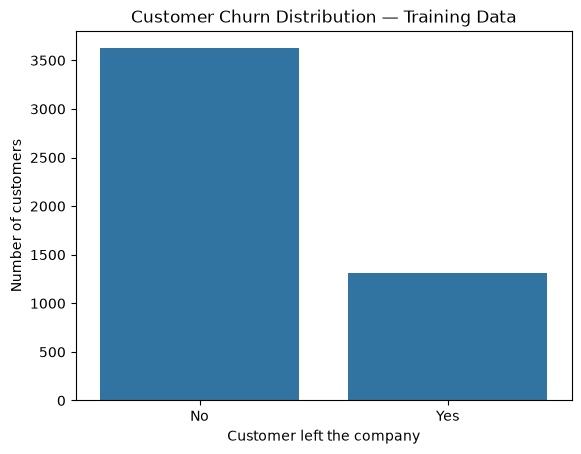

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine training inputs and labels for exploration.
train_df = X_train.copy()
train_df["Churn"] = y_train.map({0: "No", 1: "Yes"})

sns.countplot(data=train_df, x="Churn", order=["No", "Yes"])
plt.title("Customer Churn Distribution — Training Data")
plt.xlabel("Customer left the company")
plt.ylabel("Number of customers")
plt.show()

**Insight: Churn distribution**

Approximately 26.5% of training customers churned and 73.5% stayed.
Always predicting "stayed" would achieve about 73.5% training accuracy
while identifying no churners. Accuracy alone is therefore insufficient.

**Business implication:** evaluate precision, recall, F1, and the confusion
matrix when assessing usefulness for retention outreach.

### 2.2 Customer/service characteristics

**Definition:** The composition of the customer base, such as its mix of contracts and internet-service categories.

The tables below describe the contract and internet-service mix in the
training subset. These group sizes give context to the churn-rate charts.
Within-group rates are used for comparisons because raw churn counts
can be larger simply because one service group contains more customers.

In [12]:
for column in ["Contract", "InternetService"]:
    print(column)
    display(train_df[column].value_counts().rename_axis(column).to_frame("Training customers"))

Contract


,Training customers
Contract,
Month-to-month,2704
Two year,1192
One year,1034


InternetService


,Training customers
InternetService,
Fiber optic,2177
DSL,1685
No,1068


### 2.3 Churn against important customer attributes

**Definition:** Compare churn outcomes within groups defined by relevant customer attributes to identify associations worth investigating.

#### Chart 2: Contract type and churn

Calculate the proportion who churned within each contract category.

,Churn rate (%)
Contract,
Month-to-month,42.86
One year,10.93
Two year,3.02


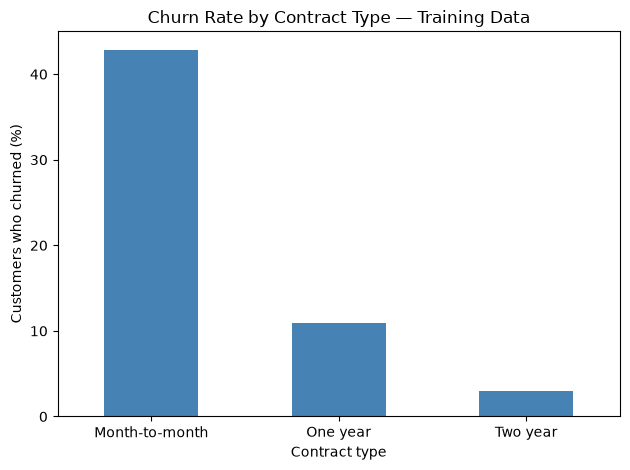

In [13]:
contract_churn = (
    train_df.assign(ChurnFlag=y_train)
    .groupby("Contract")["ChurnFlag"]
    .mean()
    .mul(100)
    .reindex(["Month-to-month", "One year", "Two year"])
)

display(contract_churn.round(2).rename("Churn rate (%)").to_frame())

contract_churn.plot(kind="bar", color="steelblue")
plt.title("Churn Rate by Contract Type — Training Data")
plt.xlabel("Contract type")
plt.ylabel("Customers who churned (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight: Churn by contract type**

In the training data, churn rates are:

- Month-to-month: 42.86%
- One year: 10.93%
- Two year: 3.02%

Month-to-month contracts are associated with substantially higher churn.
This relationship does not prove that changing a customer's contract
would prevent them from leaving.

Business implication: Month-to-month customers are a useful group to
prioritize for investigating dissatisfaction and testing retention offers.

#### Chart 3: Internet service and churn

Compare churn rates within fiber-optic, DSL, and no-internet groups.
Here `No` describes the internet service, not the churn outcome.

,Churn rate (%)
InternetService,
Fiber optic,41.85
DSL,19.17
No,6.93


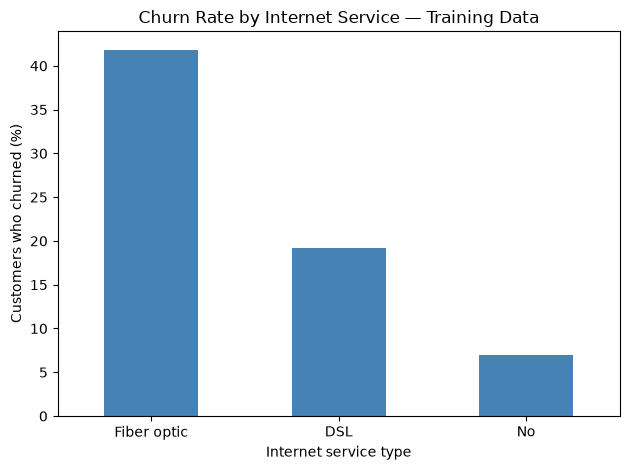

In [14]:
internet_churn = (
    train_df.assign(ChurnFlag=y_train)
    .groupby("InternetService")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(internet_churn.round(2).rename("Churn rate (%)").to_frame())

internet_churn.plot(kind="bar", color="steelblue")
plt.title("Churn Rate by Internet Service — Training Data")
plt.xlabel("Internet service type")
plt.ylabel("Customers who churned (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight: Internet service and churn**

In the training data, churn rates differ by internet service:

- Fiber optic: 41.85%
- DSL: 19.17%
- No internet service: 6.93%

Fiber optic customers have the highest observed churn rate.
This does not prove that fiber optic service causes churn;
pricing, contract type, and other customer characteristics
may contribute to the difference.

Business implication: Investigate pricing, service reliability,
and support experiences among fiber optic customers to identify
potential retention opportunities.

### 2.4 Numerical variable distributions/relationships

**Definition:** A distribution describes the spread of numerical values; comparing those distributions across churn groups examines their relationship with churn.

#### Chart 4: Tenure distribution by churn status

Compare customer-duration distributions using a box plot and summary
statistics. The median line represents the middle tenure value, and the
box spans the middle half of each group's values.

,count,median,mean
Churn,,,
No,3622,38.0,37.56
Yes,1308,10.0,18.38


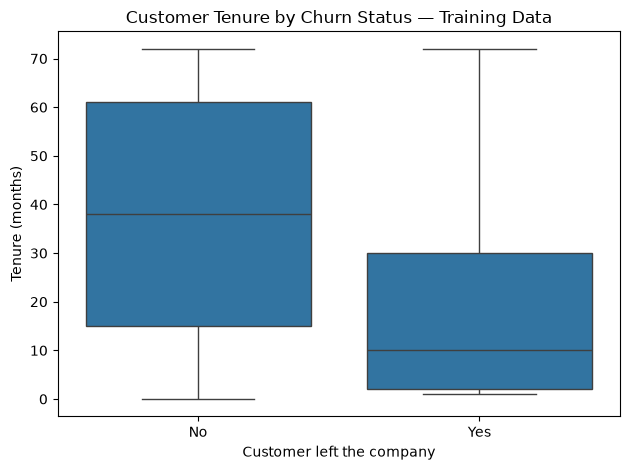

In [15]:
display(
    train_df.groupby("Churn")["tenure"]
    .agg(["count", "median", "mean"])
    .round(2)
)

sns.boxplot(
    data=train_df,
    x="Churn",
    y="tenure",
    order=["No", "Yes"]
)
plt.title("Customer Tenure by Churn Status — Training Data")
plt.xlabel("Customer left the company")
plt.ylabel("Tenure (months)")
plt.tight_layout()
plt.show()

**Insight: Customer tenure and churn**

| Churn status | Customers | Mean tenure | Median tenure |
|---|---:|---:|---:|
| Stayed (No) | 3,622 | 37.56 months | 38 months |
| Left (Yes) | 1,308 | 18.38 months | 10 months |

Customers who left generally had shorter tenure. A median of 10 months
means at least half of the customers who left had tenure of 10 months or
less. It does not mean half of all new customers leave within 10 months.

**Business implication:** investigate onboarding, early bills, and service
experiences. The association does not establish a cause of churn.


#### Chart 5: Monthly-charge distribution by churn status

Compare the charges paid by customers who stayed with those who left.
Means, medians, and overlapping distributions provide complementary views.

,count,median,mean
Churn,,,
No,3622,64.45,61.32
Yes,1308,80.00,75.00


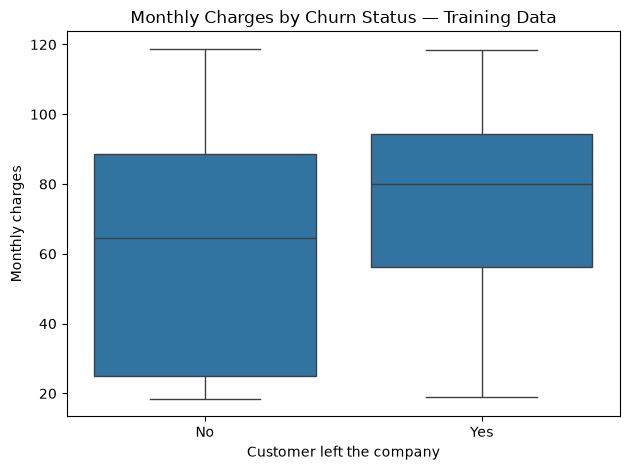

In [16]:
display(
    train_df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "median", "mean"])
    .round(2)
)

sns.boxplot(
    data=train_df,
    x="Churn",
    y="MonthlyCharges",
    order=["No", "Yes"]
)
plt.title("Monthly Charges by Churn Status — Training Data")
plt.xlabel("Customer left the company")
plt.ylabel("Monthly charges")
plt.tight_layout()
plt.show()

**Insight: Monthly charges and churn**

| Churn status | Mean monthly charges | Median monthly charges |
|---|---:|---:|
| Stayed (No) | 61.32 | 64.45 |
| Left (Yes) | 75.00 | 80.00 |

Churners had higher mean and median monthly charges in the training data,
but the distributions overlap substantially. Charges alone do not clearly
separate customers who will stay from those who will leave.

**Business implication:** investigate perceived value in higher-priced
plans. Contract and service differences may help explain the association;
this is not evidence that increasing charges causes churn.


### 2.5 Provide a brief business insight for each major visualization

Each chart has an adjacent interpretation. This summary makes those
business implications explicit in one place.

| Visualization | Business insight |
|---|---|
| Churn distribution | Class imbalance makes accuracy alone insufficient for retention screening |
| Contract and churn | Investigate dissatisfaction and retention offers among month-to-month customers |
| Internet service and churn | Investigate pricing, reliability, and support among fiber-optic customers |
| Tenure by churn | Review the early customer experience, including onboarding and initial billing |
| Monthly charges by churn | Investigate perceived value among customers on higher-priced plans |

These are opportunities for investigation, not demonstrated causes of churn
or evidence that a particular intervention will prevent customers leaving.

## 3. Feature Engineering

### 3.0 Create at least 2 meaningful features that could potentially improve churn prediction

**Definition:** feature engineering creates additional representations of
existing inputs to expose potentially useful information to a model.

**Implementation:** TenureGroup and ServiceCount are created from customer
inputs without using the Churn label. The original inputs remain available.
Their usefulness is checked through training-data validation rather than
assumed from their design. The PDF requires their creation and rationale;
it does not guarantee that they will improve every tested model.

### 3.1 Feature 1: TenureGroup

**Definition:** a categorical representation of customer tenure stages.

#### 3.1.1 How it was created

The transformer applies pd.cut to tenure using 0-12, 13-24, 25-48, and
over 48 months. For example, tenure of 8 maps to 0-12 months, while
tenure of 60 maps to Over 48 months. These fixed ranges are design choices.
The following output shows the original tenure beside its derived group.

In [17]:
engineered_preview = CustomerPreprocessor(add_features=True).fit_transform(X_train)
train_df["TenureGroup"] = engineered_preview["TenureGroup"]
display(train_df[["tenure", "TenureGroup"]].head(10))

,tenure,TenureGroup
5557,5,0-12 months
2270,3,0-12 months
6930,3,0-12 months
2257,60,Over 48 months
898,12,0-12 months
3828,65,Over 48 months
2147,18,13-24 months
3149,8,0-12 months
5401,31,25-48 months
2062,66,Over 48 months


#### 3.1.2 Why it may be useful

The groups describe interpretable stages in a customer relationship. The
training EDA found different tenure distributions among customers who
stayed and left. A Decision Tree can already split numerical tenure, so
this grouping may be redundant; the model comparisons test that possibility.

### 3.2 Feature 2: ServiceCount

**Definition:** the number of counted services to which a customer subscribes.

#### 3.2.1 How it was created

Add one for each subscribed service among phone, internet, online security,
online backup, device protection, tech support, streaming TV, and streaming
movies. The result ranges from 0 to 8. A customer with phone, internet,
and streaming TV has a count of 3.

MultipleLines is not counted separately because it extends phone service.
Missing or unrecognized service information leaves the total missing for
later imputation instead of interpreting an unknown subscription as absent.

In [18]:
train_df["ServiceCount"] = engineered_preview["ServiceCount"]
display(
    train_df[YES_NO_SERVICES + ["InternetService", "ServiceCount"]].head(10)
)

,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService,ServiceCount
5557,Yes,No,No,No,No,Yes,No,Fiber optic,3.0
2270,Yes,No,No,Yes,No,Yes,No,Fiber optic,4.0
6930,Yes,No,No,No,No,No,No,Fiber optic,2.0
2257,Yes,No,No,Yes,Yes,Yes,Yes,DSL,6.0
898,Yes,Yes,No,No,Yes,Yes,Yes,Fiber optic,6.0
3828,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,1.0
2147,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,1.0
3149,Yes,No,No,Yes,Yes,No,Yes,DSL,5.0
5401,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,1.0
2062,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,1.0


#### 3.2.2 Why it may be useful

The original service fields identify which services a customer uses. This
feature summarizes how many they use, which may help represent the breadth
of the relationship. More subscriptions are not assumed to cause lower
churn; the group analysis and validation comparisons examine the pattern.

### 3.3 Feature exploration and usefulness

Compare customer counts and churn rates within the engineered groups.
These are associations, not evidence that changing tenure or adding a
service will cause retention.

In [19]:
for feature in ["TenureGroup", "ServiceCount"]:
    summary = (
        train_df.assign(ChurnFlag=y_train)
        .groupby(feature, observed=True)["ChurnFlag"]
        .agg(Customers="size", ChurnRate="mean")
    )

    summary["ChurnRate"] = (summary["ChurnRate"] * 100).round(2)
    summary = summary.rename(columns={"ChurnRate": "Churn rate (%)"})

    print(f"\nChurn by {feature}")
    display(summary)


Churn by TenureGroup


,Customers,Churn rate (%)
TenureGroup,,
0-12 months,1537,47.69
13-24 months,707,27.30
25-48 months,1118,19.95
Over 48 months,1568,10.14



Churn by ServiceCount


,Customers,Churn rate (%)
ServiceCount,,
1.0,1121,8.65
2.0,497,49.90
3.0,687,44.54
4.0,735,35.78
5.0,734,27.25
6.0,592,22.64
7.0,366,13.66
8.0,198,5.05


**Insights from engineered features**

**TenureGroup:** Churn rates decrease across the tenure groups:
47.69% for 0–12 months, 27.30% for 13–24 months, 19.95% for
25–48 months, and 10.14% for over 48 months.

This suggests prioritizing investigation of the early customer
experience when designing retention initiatives.

**ServiceCount:** Customers with 2 services have the highest churn
rate (49.90%). Rates then decrease across groups with 3–8 services,
reaching 5.05% for 8 services. However, the 1-service group also has
a low churn rate (8.65%), so the overall relationship is not a
consistent decline.

Service count should be interpreted alongside the types of services,
contract, and tenure. These findings do not prove that adding services
will prevent churn.

Both features show associations with churn in the training data.
We will use cross-validation to assess whether they improve prediction
beyond the original inputs.

### 3.4 Consistent feature implementation

The same `CustomerPreprocessor` is used for notebook exploration and the
model pipeline. This preview verifies that it adds two columns and converts
numerical inputs. Learned imputation and encoding still occur later,
inside training folds.

In [20]:
preprocessor = CustomerPreprocessor(add_features=True)
prepared_train = preprocessor.fit_transform(X_train)

print("Original training shape:", X_train.shape)
print("Transformed training shape:", prepared_train.shape)
print("TotalCharges type:", prepared_train["TotalCharges"].dtype)
display(prepared_train[
    ["tenure", "TenureGroup", "ServiceCount", "TotalCharges"]
].head())

Original training shape: (4930, 19)
Transformed training shape: (4930, 21)
TotalCharges type: float64


,tenure,TenureGroup,ServiceCount,TotalCharges
5557,5,0-12 months,3.0,384.25
2270,3,0-12 months,4.0,220.95
6930,3,0-12 months,2.0,216.75
2257,60,Over 48 months,6.0,4847.05
898,12,0-12 months,6.0,1120.95


## 4. Model Development

### 4.1 Build a Decision Tree Classifier

**Definition:** A supervised classifier learns a sequence of feature-based questions from labelled customers and assigns a class at the resulting leaf.

A Decision Tree partitions customer records using feature conditions.
Gini impurity and entropy measure how mixed the classes are when evaluating
splits. Depth and minimum leaf size limit how specific its rules become.

Each model contains the fixed customer transformer, numerical/categorical
preprocessing, and a Decision Tree with `random_state=42`. Separate
pipelines keep feature creation and column selection aligned when comparing
the original inputs with the two engineered features.

In [21]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier


def build_model_pipeline(add_features=True, **tree_settings):
    numeric_columns = numerical_features.copy()
    categorical_columns = categorical_features.copy()

    if add_features:
        numeric_columns.append("ServiceCount")
        categorical_columns.append("TenureGroup")

    column_preprocessor = ColumnTransformer([
        ("numeric", clone(numerical_pipeline), numeric_columns),
        ("categorical", clone(categorical_pipeline), categorical_columns)
    ])

    return Pipeline([
        ("customer_features", CustomerPreprocessor(
            add_features=add_features
        )),
        ("column_preprocessing", column_preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            **tree_settings
        ))
    ])


baseline_pipeline = build_model_pipeline()

print("Complete model pipeline created. Training has not started yet.")

Complete model pipeline created. Training has not started yet.


### 4.2 Experiment with at least two different Decision Tree configurations

**Definition:** Change model settings while retaining a consistent validation method so their effect on performance can be compared.

**Comparison method:** five-fold stratified cross-validation uses four
training folds for fitting and one for validation, rotating each round.
Every candidate uses the same splits. Scikit-learn's `test_*` score keys
refer to validation folds of `X_train`, not the separate `X_test`.

#### Configuration 1: Unrestricted baseline

The baseline allows a fully grown tree. Training and validation scores
reveal whether its detailed rules generalize to unseen customers.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

baseline_summary = pd.DataFrame({
    "Training mean": {
        metric: baseline_results[f"train_{metric}"].mean()
        for metric in scoring
    },
    "Validation mean": {
        metric: baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    }
})

display(baseline_summary.round(3))

,Training mean,Validation mean
accuracy,0.998,0.738
precision,1.000,0.505
recall,0.994,0.524
f1,0.997,0.514


**Baseline interpretation and complexity control**

The original run produced training accuracy of 0.998 and validation
accuracy of 0.738. This large gap indicates overfitting: training-specific
patterns did not generalize well to validation customers. The tables above
regenerate scores for the installed environment.

The next candidate limits depth to 5 and requires at least 20 training
customers per leaf. These initial limits test whether less complex rules
reduce overfitting; they are not assumed to be optimal.

#### Configuration 2: Constrained tree

Set `max_depth=5` and `min_samples_leaf=20` to limit complex rules and
small leaves. The validation method and splits remain the same.

In [23]:
constrained_pipeline = build_model_pipeline(
    max_depth=5,
    min_samples_leaf=20
)

constrained_results = cross_validate(
    constrained_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

constrained_summary = pd.DataFrame({
    "Training mean": {
        metric: constrained_results[f"train_{metric}"].mean()
        for metric in scoring
    },
    "Validation mean": {
        metric: constrained_results[f"test_{metric}"].mean()
        for metric in scoring
    }
})

display(constrained_summary.round(3))

,Training mean,Validation mean
accuracy,0.804,0.790
precision,0.659,0.625
recall,0.553,0.528
f1,0.597,0.569


### 4.3 Compare the models

**Definition:** Evaluate candidate performance on the same validation splits and inspect both predictive scores and training-validation gaps.

The table directly compares the baseline and constrained model on mean
validation accuracy, precision, recall, and F1. Training-validation gaps
are also inspected to assess overfitting.

In [24]:
comparison = pd.DataFrame({
    "Baseline validation": baseline_summary["Validation mean"],
    "Constrained validation": constrained_summary["Validation mean"]
})

display(comparison.round(3))

,Baseline validation,Constrained validation
accuracy,0.738,0.790
precision,0.505,0.625
recall,0.524,0.528
f1,0.514,0.569


**Constrained model interpretation**

In the original run, the constrained tree increased validation F1 from
0.514 to 0.569 and reduced the accuracy gap from 26.0 to 1.4 percentage
points. Recall remained near 0.53, leaving many churners unidentified.

#### Engineered features: initial comparison

The following comparison holds the unweighted tree settings and validation
splits constant. It evaluates whether the two added features improve this
particular configuration beyond the original inputs.

In [25]:
without_features_pipeline = build_model_pipeline(
    add_features=False,
    max_depth=5,
    min_samples_leaf=20
)

without_features_results = cross_validate(
    without_features_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

feature_comparison = pd.DataFrame({
    "Without engineered features": {
        metric: without_features_results[f"test_{metric}"].mean()
        for metric in scoring
    },
    "With engineered features": {
        metric: constrained_results[f"test_{metric}"].mean()
        for metric in scoring
    }
})

display(feature_comparison.round(3))

,Without engineered features,With engineered features
accuracy,0.790,0.790
precision,0.625,0.625
recall,0.528,0.528
f1,0.569,0.569


**Engineered-feature comparison: interpretation**

The original unweighted comparison produced identical mean metrics to six
decimal places, with matching displayed F1 in each fold. No improvement
was observed for that configuration. Matching scores alone do not prove
identical predictions or establish that the features are always redundant.

The later search evaluates both feature choices under every tree setting,
including balanced class weights.

In [26]:
display(feature_comparison.round(6))

print("Validation F1 for each fold:")
display(pd.DataFrame({
    "Without features": without_features_results["test_f1"],
    "With features": constrained_results["test_f1"]
}, index=[1, 2, 3, 4, 5]).rename_axis("Fold"))

,Without engineered features,With engineered features
accuracy,0.789655,0.789655
precision,0.624556,0.624556
recall,0.528317,0.528317
f1,0.568985,0.568985


Validation F1 for each fold:


,Without features,With features
Fold,,
1,0.551148,0.551148
2,0.609901,0.609901
3,0.505910,0.505910
4,0.564103,0.564103
5,0.613861,0.613861


**Balanced class weights**

Because churners form the smaller group, balanced weights give their
records more influence during fitting. The following comparison keeps the
original inputs and tree limits constant to isolate the effect of weights.
This may increase recall while reducing precision and accuracy.

In [27]:
balanced_pipeline = build_model_pipeline(
    add_features=False,
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced"
)

balanced_results = cross_validate(
    balanced_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

weight_comparison = pd.DataFrame({
    "Normal weights": {
        metric: without_features_results[f"test_{metric}"].mean()
        for metric in scoring
    },
    "Balanced weights": {
        metric: balanced_results[f"test_{metric}"].mean()
        for metric in scoring
    }
})

display(weight_comparison.round(3))

,Normal weights,Balanced weights
accuracy,0.790,0.740
precision,0.625,0.508
recall,0.528,0.778
f1,0.569,0.613


### 4.4 Train the model on the training dataset

**Definition:** Fitting learns the preprocessing statistics and the classifier from training inputs paired with known churn labels.

The first development round selected a balanced tree with depth 5,
minimum leaf size 20, and original inputs. It improved validation recall
and F1 relative to the unweighted constrained tree, at a cost to precision.

The following cell fits that initial benchmark on all 4,930 training
customers. It remains available for comparison with the later tuned
candidate. No test record is used for fitting.

In [28]:
initial_pipeline = build_model_pipeline(
    add_features=False,
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced"
)
initial_pipeline.fit(X_train, y_train)
final_pipeline = initial_pipeline

print("Initial pipeline trained on", len(X_train), "customers.")
print("Classes:", initial_pipeline.named_steps["classifier"].classes_)

Initial pipeline trained on 4930 customers.
Classes: [0 1]


### 4.5 Additional improvement: hyperparameter tuning

All follow-up settings and feature choices are selected using `X_train`
and `y_train`. The original split and random seed are retained.

**Selection rule fixed before this search:** maximize mean validation F1,
while reporting precision, recall, accuracy, and variation across folds.
F1 is a practical compromise between precision and recall when campaign
costs and a minimum acceptable recall are unspecified. It does not give
recall extra weight or optimize retention profit. A higher-F1 candidate
can therefore catch fewer churners; that trade-off is reported explicitly.

| Setting | Candidates | Reason for comparison |
|---|---|---|
| Maximum depth | 3, 5, 7 | Control the complexity of decision paths |
| Minimum samples per leaf | 10, 20, 40 | Limit rules based on small groups |
| Split criterion | gini, entropy | Compare ways of measuring split quality |
| Class weights | normal, churn weight 2, balanced | Compare minority-class emphasis |
| Engineered features | off, on | Reassess whether the additional inputs help |

There are 54 tree configurations per feature choice: 108 candidates and
540 validation fits, plus refitting the winners. Each feature choice has
its own complete pipeline with the appropriate column selections.

The best search score is used for selection and may be optimistic after
trying many candidates. Fold standard deviation describes variation; it
is not a confidence interval or proof of a reproducible improvement.

In [29]:
from sklearn.model_selection import GridSearchCV, ParameterGrid

param_grid = {
    "classifier__max_depth": [3, 5, 7],
    "classifier__min_samples_leaf": [10, 20, 40],
    "classifier__criterion": ["gini", "entropy"],
    "classifier__class_weight": [None, {0: 1, 1: 2}, "balanced"]
}

print("Tree configurations per feature choice:", len(list(ParameterGrid(param_grid))))
print("Total candidates:", 2 * len(list(ParameterGrid(param_grid))))
print("Only X_train and y_train will be supplied to the searches.")

Tree configurations per feature choice: 54
Total candidates: 108
Only X_train and y_train will be supplied to the searches.


In [30]:
searches = {}
search_tables = []

for add_features in [False, True]:
    label = "With engineered features" if add_features else "Original inputs only"
    print("Starting:", label)

    search = GridSearchCV(
        estimator=build_model_pipeline(add_features=add_features),
        param_grid=param_grid,
        scoring=scoring,
        refit="f1",
        cv=cv,
        n_jobs=1,
        return_train_score=True,
        error_score="raise",
        verbose=1
    )
    search.fit(X_train, y_train)
    searches[add_features] = search

    results_table = pd.DataFrame(search.cv_results_)
    results_table["Engineered features"] = add_features
    search_tables.append(results_table)

    print("Best mean validation F1:", round(search.best_score_, 6))
    print("Best settings:", search.best_params_)

search_results = pd.concat(search_tables, ignore_index=True)
ranked_results = search_results.sort_values(
    ["mean_test_f1", "Engineered features"],
    ascending=[False, True],
    kind="stable"
).reset_index(drop=True)

display_columns = [
    "Engineered features",
    "param_classifier__max_depth",
    "param_classifier__min_samples_leaf",
    "param_classifier__criterion",
    "param_classifier__class_weight",
    "mean_train_f1", "mean_test_f1", "std_test_f1",
    "mean_test_precision", "mean_test_recall", "mean_test_accuracy"
]
display(ranked_results[display_columns].head(10).round(4))

Starting: Original inputs only
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best mean validation F1: 0.623921
Best settings: {'classifier__class_weight': {0: 1, 1: 2}, 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 40}
Starting: With engineered features
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best mean validation F1: 0.623921
Best settings: {'classifier__class_weight': {0: 1, 1: 2}, 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 40}


,Engineered features,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__criterion,param_classifier__class_weight,mean_train_f1,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall,mean_test_accuracy
0,False,5,40,gini,"{0: 1, 1: 2}",0.6451,0.6239,0.0305,0.5523,0.7171,0.7704
1,True,5,40,gini,"{0: 1, 1: 2}",0.6451,0.6239,0.0305,0.5523,0.7171,0.7704
2,False,5,20,gini,"{0: 1, 1: 2}",0.6460,0.6230,0.0272,0.5515,0.7164,0.7698
3,True,5,20,gini,"{0: 1, 1: 2}",0.6460,0.6230,0.0272,0.5515,0.7164,0.7698
4,False,5,10,gini,"{0: 1, 1: 2}",0.6476,0.6194,0.0288,0.5466,0.7156,0.7663
5,True,5,10,gini,"{0: 1, 1: 2}",0.6476,0.6194,0.0288,0.5466,0.7156,0.7663
6,False,5,40,entropy,"{0: 1, 1: 2}",0.6444,0.6188,0.0301,0.5482,0.7110,0.7671
7,True,5,40,entropy,"{0: 1, 1: 2}",0.6444,0.6188,0.0301,0.5482,0.7110,0.7671
8,False,5,20,entropy,"{0: 1, 1: 2}",0.6452,0.6183,0.0253,0.5469,0.7118,0.7665
9,True,5,20,entropy,"{0: 1, 1: 2}",0.6452,0.6183,0.0253,0.5469,0.7118,0.7665


### 4.6 Recheck engineered features under balanced class weights

The table below compares the two feature choices specifically for the
initial balanced configuration: depth 5, minimum leaf size 20, and Gini.
Its scores are retrieved from the completed search. This addresses the
limitation of the earlier feature comparison, which used an unweighted
tree.

In [31]:
balanced_feature_rows = []
for add_features, search in searches.items():
    table = pd.DataFrame(search.cv_results_)
    wanted = table["params"].map(lambda params: (
        params["classifier__max_depth"] == 5
        and params["classifier__min_samples_leaf"] == 20
        and params["classifier__criterion"] == "gini"
        and params["classifier__class_weight"] == "balanced"
    ))
    row = table.loc[wanted].iloc[0]
    balanced_feature_rows.append({
        "Engineered features": add_features,
        **{metric: row[f"mean_test_{metric}"] for metric in scoring},
        "F1 fold std": row["std_test_f1"]
    })

display(pd.DataFrame(balanced_feature_rows).set_index("Engineered features").round(6))

,accuracy,precision,recall,f1,F1 fold std
Engineered features,,,,,
False,0.739554,0.507517,0.778252,0.613471,0.019821
True,0.738540,0.506174,0.778252,0.612500,0.018680


### 4.7 Select and justify the final model

**Definition:** Choose a candidate using a declared evaluation rule and explain its advantages and limitations relative to alternatives.

The feature choice with the highest mean validation F1 is selected. When
the best means tie within numerical precision, original inputs are
preferred. GridSearchCV refits the winner using all training records.

The following table compares the selected candidate with the initial
balanced model, including fold variation. The printed settings identify
the exact selected tree. Selection uses no test metric. The rationale is
the declared F1 criterion, rather than a claim that the model is best on
every metric or necessarily the most profitable retention strategy.

In [32]:
without_score = searches[False].best_score_
with_score = searches[True].best_score_
scores_tied = np.isclose(with_score, without_score, atol=1e-12, rtol=0)
selected_add_features = bool(with_score > without_score and not scores_tied)

selected_search = searches[selected_add_features]
tuned_pipeline = selected_search.best_estimator_
final_pipeline = tuned_pipeline

selected_row = pd.DataFrame(selected_search.cv_results_).iloc[
    selected_search.best_index_
]
selection_summary = pd.DataFrame({
    "Initial CV mean": {
        metric: balanced_results[f"test_{metric}"].mean() for metric in scoring
    },
    "Initial CV fold std": {
        metric: balanced_results[f"test_{metric}"].std() for metric in scoring
    },
    "Selected CV mean": {
        metric: selected_row[f"mean_test_{metric}"] for metric in scoring
    },
    "Selected CV fold std": {
        metric: selected_row[f"std_test_{metric}"] for metric in scoring
    }
})
display(selection_summary.round(4))
print("Engineered features selected:", selected_add_features)
print("Selected tree settings:", selected_search.best_params_)
print("Mean CV F1 change:", round(
    selected_search.best_score_ - balanced_results["test_f1"].mean(), 6
))

,Initial CV mean,Initial CV fold std,Selected CV mean,Selected CV fold std
accuracy,0.7396,0.0205,0.7704,0.0206
precision,0.5075,0.0251,0.5523,0.0312
recall,0.7783,0.0392,0.7171,0.0305
f1,0.6135,0.0198,0.6239,0.0305


Engineered features selected: False
Selected tree settings: {'classifier__class_weight': {0: 1, 1: 2}, 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 40}
Mean CV F1 change: 0.01045


### 4.8 Final model fitted on the complete training subset

`GridSearchCV(refit="f1")` has refitted the selected candidate on all
4,930 training customers. `final_pipeline` now refers to that fitted
pipeline, including its learned preprocessing. Its printed settings and
comparison table document the choice. The separate test set has not been
supplied to the search or refit calls.

## 5. Model Evaluation

The selected candidate and initial benchmark are evaluated on the same
2,113 test customers. Because initial test results were inspected before
follow-up development, this is a reused test-set comparison rather than
new independent validation. No candidate is chosen using these scores.

**Initial benchmark reference**

The following cell reproduces the initial model's metrics and confusion
matrix. The final selected candidate is evaluated immediately afterward.

,Test score
Accuracy,0.711
Precision,0.474
Recall,0.799
F1,0.595


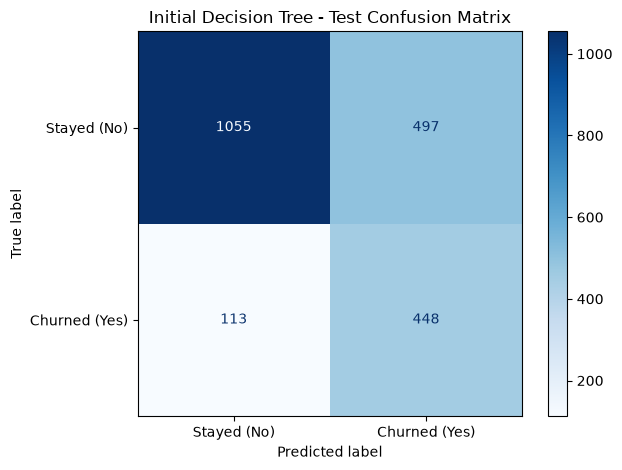

Correctly predicted stayed: 1055
Stayed but predicted churn: 497
Churned but predicted stayed: 113
Correctly predicted churn: 448


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_test_pred = initial_pipeline.predict(X_test)

test_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1": f1_score(y_test, y_test_pred, zero_division=0)
})

display(test_metrics.round(3).to_frame("Test score"))

test_cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["Stayed (No)", "Churned (Yes)"]
).plot(cmap="Blues", values_format="d")

plt.title("Initial Decision Tree - Test Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = test_cm.ravel()
print("Correctly predicted stayed:", tn)
print("Stayed but predicted churn:", fp)
print("Churned but predicted stayed:", fn)
print("Correctly predicted churn:", tp)

**Initial evaluation: interpretation and limitations**

The original Windows run reported accuracy 0.711, precision 0.474,
recall 0.799, and F1 0.595. Its counts were 1,055 true negatives,
497 false positives, 113 false negatives, and 448 true positives.
The preceding cell regenerates metrics for the installed environment.

The model identified most churners but more than half of its flags were
false alarms. Accuracy was below the approximately 73.5% of an
always-stayed rule, which has zero recall for churners.

These results support investigating inexpensive retention screening;
they do not establish profitability or operational readiness.

### 5.1 Accuracy

**Definition:** the proportion of all customers classified correctly.

**Calculation:** (TP + TN) / (TP + TN + FP + FN), implemented with
accuracy_score. Here TP means correctly identified churners, TN correctly
identified stayers, FP false churn alerts, and FN missed churners.

**Interpretation:** accuracy counts both classes but can conceal poor churn
detection in an imbalanced dataset. It is reported with the other metrics.

### 5.2 Precision

**Definition:** among customers predicted to churn, the proportion who
actually churned.

**Calculation:** TP / (TP + FP), using precision_score with churn/1 as the
positive class. For example, precision of 0.60 means about 60 of every
100 flagged customers actually churned.

**Business meaning:** lower precision implies more unnecessary outreach
among the customers flagged for retention activity.

### 5.3 Recall

**Definition:** among customers who actually churned, the proportion
identified by the model.

**Calculation:** TP / (TP + FN), using recall_score with churn/1 as positive.
Recall of 0.80 means identifying about 80 of every 100 actual churners.

**Business meaning:** lower recall leaves more churners unidentified for
targeted outreach.

### 5.4 F1 Score

**Definition:** the harmonic mean of precision and recall.

**Calculation:** 2 * TP / (2 * TP + FP + FN), implemented with f1_score.
It gives a combined view of false alarms and missed churners, without
assigning campaign costs or giving recall extra weight.


In [34]:
tuned_test_pred = tuned_pipeline.predict(X_test)
tuned_test_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, tuned_test_pred),
    "Precision": precision_score(y_test, tuned_test_pred, zero_division=0),
    "Recall": recall_score(y_test, tuned_test_pred, zero_division=0),
    "F1": f1_score(y_test, tuned_test_pred, zero_division=0)
})

test_comparison = pd.DataFrame({
    "Initial model": test_metrics,
    "Tuned candidate (reused test)": tuned_test_metrics
})
display(test_comparison.round(4))

,Initial model,Tuned candidate (reused test)
Accuracy,0.7113,0.7619
Precision,0.4741,0.5387
Recall,0.7986,0.7201
F1,0.5950,0.6163


### 5.5 Confusion Matrix

**Definition:** a table of actual versus predicted outcomes that makes
correct predictions and the two kinds of errors explicit.

| Actual outcome | Predicted stayed | Predicted churn |
|---|---|---|
| Stayed | True negative (TN) | False positive (FP) |
| Churned | False negative (FN) | True positive (TP) |

**Implementation:** confusion_matrix fixes class order as 0, then 1.
The following plot and printed values show the selected candidate's actual
customer counts. These counts are not weighted; class weights influence
training, while this evaluation counts each test customer once.

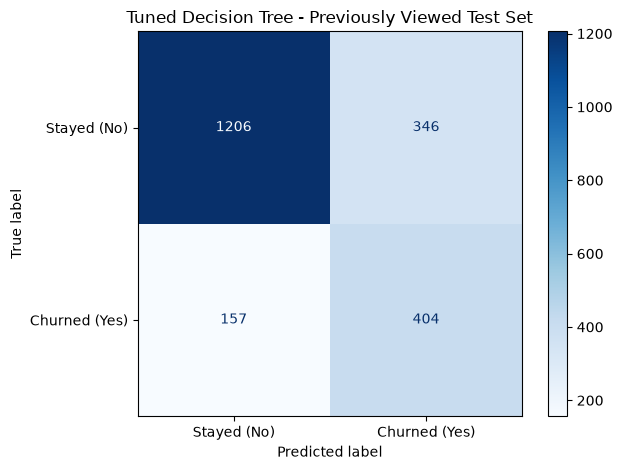

Correctly predicted stayed: 1206
Stayed but predicted churn: 346
Churned but predicted stayed: 157
Correctly predicted churn: 404
Flagged customers: 750
Actual churners: 561


In [35]:
tuned_cm = confusion_matrix(y_test, tuned_test_pred, labels=[0, 1])
ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=["Stayed (No)", "Churned (Yes)"]
).plot(cmap="Blues", values_format="d")
plt.title("Tuned Decision Tree - Previously Viewed Test Set")
plt.tight_layout()
plt.show()

tuned_tn, tuned_fp, tuned_fn, tuned_tp = tuned_cm.ravel()
print(f"Correctly predicted stayed: {tuned_tn}")
print(f"Stayed but predicted churn: {tuned_fp}")
print(f"Churned but predicted stayed: {tuned_fn}")
print(f"Correctly predicted churn: {tuned_tp}")
print(f"Flagged customers: {tuned_tp + tuned_fp}")
print(f"Actual churners: {tuned_tp + tuned_fn}")

### 5.6 Interpret the results from a business perspective

True positives are churners identified for potential outreach. False
negatives are missed opportunities to contact customers who leave. False
positives are customers who stayed but would have been contacted, potentially
consuming staff time or incentive budgets.

The comparison table must be read as a trade-off. Higher precision with
lower recall reduces false alarms among flagged customers but misses more
actual churners. A higher F1 is not proof of higher retention profit.

### 5.7 Would you prioritize Precision or Recall? Why?

**Recall is the primary business concern for this screening use case:**
an unidentified churner receives no targeted retention outreach. Precision
still matters because unnecessary outreach has a cost.

No campaign costs or minimum recall target were supplied. The follow-up
search therefore used mean F1 as an explicitly stated compromise rather
than maximizing recall alone. F1 does not give recall extra weight. If
catching as many churners as possible takes precedence over false alarms,
the model with higher recall may be the better operational choice even
when its F1 is lower. This decision requires a business threshold or cost
model; the notebook does not claim a financially optimal solution.

## 6. Model Interpretation

### 6.1 Feature importance

**Definition:** A fitted-tree measure of the contribution of each input to reducing weighted class impurity during training.

Importance measures how much each input contributed to reducing impurity
in the selected tree's training splits. It is not the proportion of churn
caused by that input, and it does not show effect direction.

### 6.2 Top features influencing churn

**Definition:** The inputs with the largest importance values in this fitted model, rather than a list of proven causes of churn.

The following table and chart rank the ten most important nonzero inputs.
Prefixes distinguish numerical variables from encoded category indicators.
Correlated features may substitute for one another; impurity importance
can also favor variables offering many possible splits.

,Importance
categorical__Contract_Month-to-month,0.5907
numeric__tenure,0.1415
categorical__InternetService_Fiber optic,0.1202
numeric__MonthlyCharges,0.0358
categorical__PaymentMethod_Electronic check,0.0301
categorical__TechSupport_No,0.0200
categorical__OnlineSecurity_No,0.0194
numeric__TotalCharges,0.0155
categorical__MultipleLines_Yes,0.0080
categorical__StreamingMovies_No,0.0072


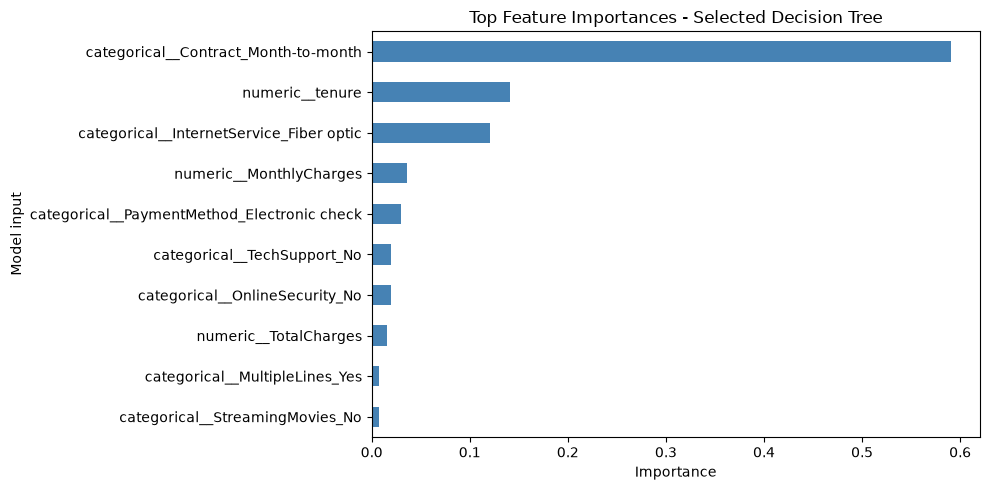

Actual fitted depth: 5
Number of leaves: 31


In [36]:
feature_names = (
    final_pipeline.named_steps["column_preprocessing"].get_feature_names_out()
)
tree_model = final_pipeline.named_steps["classifier"]
feature_importance = pd.Series(
    tree_model.feature_importances_, index=feature_names, name="Importance"
).sort_values(ascending=False)

top_features = feature_importance[feature_importance > 0].head(10)
display(top_features.round(4).to_frame())
if not top_features.empty:
    top_features.sort_values().plot(kind="barh", figsize=(10, 5), color="steelblue")
    plt.title("Top Feature Importances - Selected Decision Tree")
    plt.xlabel("Importance")
    plt.ylabel("Model input")
    plt.tight_layout()
    plt.show()

print("Actual fitted depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

### 6.3 Decision Tree visualization or appropriate interpretation

**Definition:** Inspect the learned decision conditions and branches to explain how customer information leads to predictions.

Conditions are followed from the root downward: the left branch represents
true and the right branch false. A 0.5 threshold on a one-hot indicator
separates absence from presence. The diagram displays only the first
levels; continuation boxes represent deeper decisions, and readable rules
below the diagram provide additional detail.

In the verified selected tree, the first split separates month-to-month
contracts from longer contracts. Subsequent branches use monthly charges
for longer contracts and fiber-optic service for month-to-month contracts,
with tenure providing further distinctions. This shows how several
customer attributes combine to produce a prediction.

These thresholds are learned model rules, not manually chosen business
policies. Where class weights are used, node proportions reflect those
weights and should not be treated as observed churn rates or calibrated
individual risks.

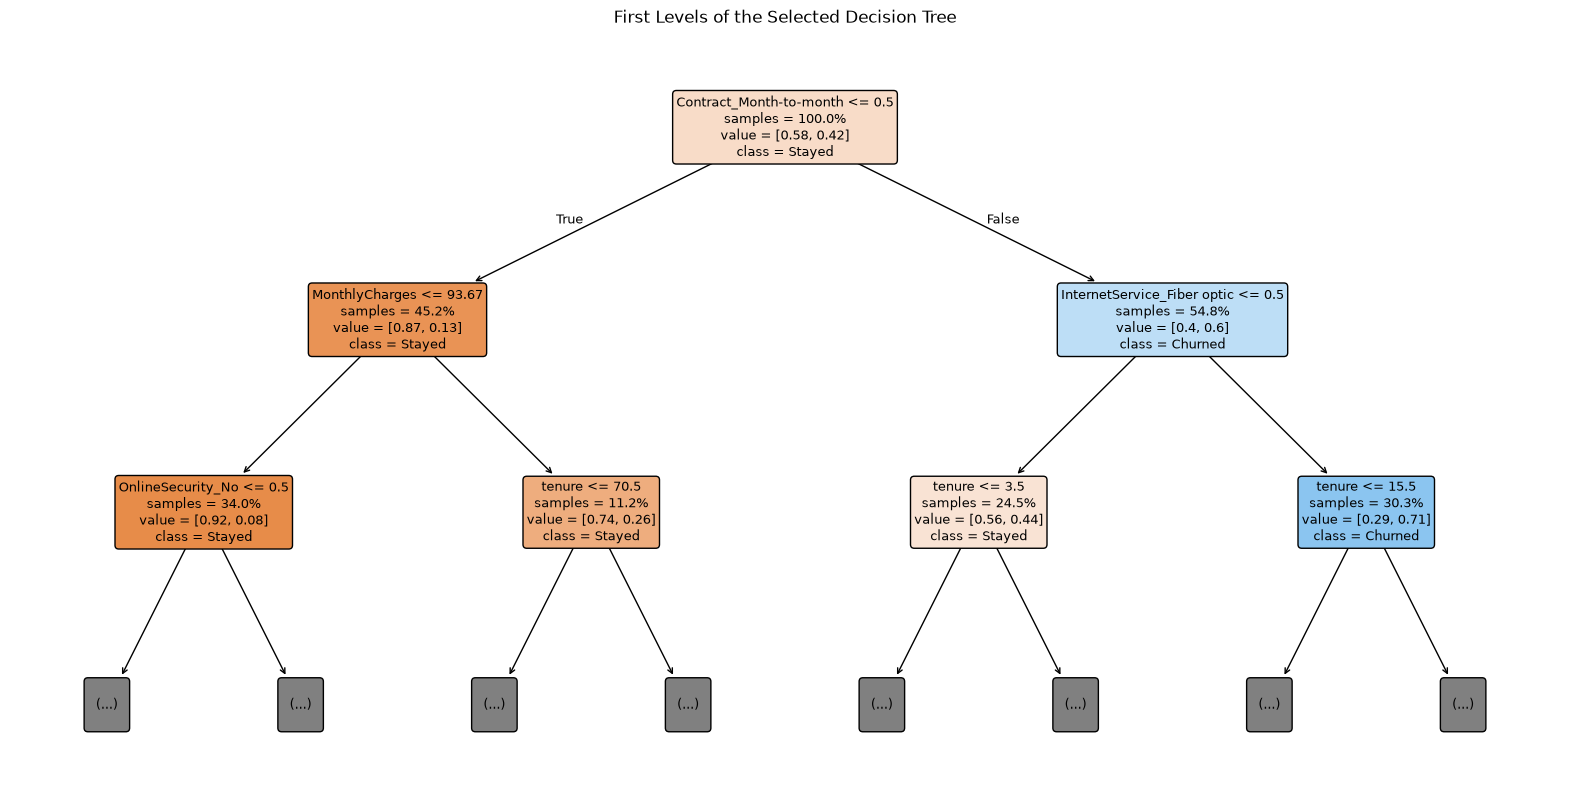

Readable rules (limited display depth):
|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- OnlineSecurity_No >  0.50
|   |   |   |--- tenure <= 49.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- tenure >  49.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- MonthlyCharges >  93.67
|   |   |--- tenure <= 70.50
|   |   |   |--- Dependents_Yes <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Dependents_Yes >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- tenure >  70.50
|   |   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- OnlineSecurity_No >  0.50
|   |   |   |   |--- class: 0
|---

In [37]:
from sklearn.tree import plot_tree, export_text

readable_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in feature_names
]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=readable_names,
    class_names=["Stayed", "Churned"],
    max_depth=2,
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    precision=2,
    fontsize=9
)
plt.title("First Levels of the Selected Decision Tree")
plt.show()

print("Readable rules (limited display depth):")
print(export_text(tree_model, feature_names=readable_names, max_depth=3))

### 6.4 Short explanation of the key findings

Contract type, tenure, and internet service are central patterns in the
training EDA and verified selected tree. Month-to-month customers,
shorter-tenure groups, and fiber-optic customers had higher observed churn
rates in the training analysis.

The early tree branches show how those attributes combine rather than
operate as isolated rules. These segments provide starting points for
investigating retention needs. Neither the EDA nor the tree establishes
that changing one attribute will cause a customer to stay.

## 7. Model Saving & API

### 7.1 Save the final model/preprocessing pipeline

**Definition:** Serialize the fitted transformations and classifier together so they can be loaded and reused without retraining.

The complete fitted pipeline is saved as
`models/churn_pipeline_tuned.joblib`. It includes input cleaning,
optional feature engineering, imputation, encoding, and the classifier.
Loading requires `src/preprocessing.py` and compatible package versions.

The reload check compares class predictions and probabilities for five
training customers. Passing verifies these outputs survive serialization;
it is separate from the predictive-performance evaluation.

For the required API, `churn_probability` will use the class-1 (Yes) score,
rather than the maximum score across classes. The tree's probability
outputs have not been calibrated as individual real-world risks.
The saved candidate retains the classifier's default prediction rule.

In [38]:
import joblib

model_path = project_root / "models" / "churn_pipeline_tuned.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_pipeline, model_path)
loaded_pipeline = joblib.load(model_path)

sample_customers = X_train.head(5)
np.testing.assert_array_equal(
    final_pipeline.predict(sample_customers),
    loaded_pipeline.predict(sample_customers)
)
np.testing.assert_allclose(
    final_pipeline.predict_proba(sample_customers),
    loaded_pipeline.predict_proba(sample_customers)
)

class_labels = loaded_pipeline.named_steps["classifier"].classes_
yes_column = int(np.flatnonzero(class_labels == 1)[0])
sample_predictions = loaded_pipeline.predict(sample_customers)
sample_probabilities = loaded_pipeline.predict_proba(sample_customers)[:, yes_column]
display(pd.DataFrame({
    "prediction": ["Yes" if value == 1 else "No" for value in sample_predictions],
    "churn_probability": sample_probabilities
}, index=sample_customers.index))

print("Saved pipeline:", model_path)
print("Reload check passed: predictions and probabilities match.")

,prediction,churn_probability
5557,Yes,0.714286
2270,Yes,0.714286
6930,Yes,0.853982
2257,No,0.021277
898,Yes,0.714286


Saved pipeline: c:\Users\visha\Documents\customer_churn_project\models\churn_pipeline_tuned.joblib
Reload check passed: predictions and probabilities match.


## Conclusion and business limitations

The workflow identifies data-quality issues, explores churn associations,
creates and evaluates two features, and compares Decision Tree
configurations without fitting preprocessing on the test set. The initial
unrestricted tree overfit; constrained and weighted candidates made the
generalization and precision-recall trade-offs explicit.

The follow-up candidate is selected by mean cross-validation F1 across
108 candidates. Its exact settings, results, and changes relative to the
initial benchmark appear in the calculated summary below. Improvements in
some metrics must be considered alongside any reduction in recall.

The model may support retention screening, but outreach costs, customer
value, and future validation are required to assess operational usefulness.
Feature importance and tree rules explain model behavior, not causes of
churn. The search score is a selection score, and the follow-up test set
had already been viewed; neither establishes guaranteed future gains.

The pipeline is saved for the next stage: a validated REST prediction API.

In [ ]:
print("SELECTED CANDIDATE")
print("Engineered features:", selected_add_features)
print("Tree settings:", selected_search.best_params_)
print(f"Mean selection CV F1: {selected_search.best_score_:.4f}")
print(f"Initial mean CV F1: {balanced_results['test_f1'].mean():.4f}")
print()
print("FOLLOW-UP RESULTS ON THE PREVIOUSLY VIEWED TEST SET")
for metric in test_comparison.index:
    initial_value = float(test_comparison.loc[metric, "Initial model"])
    tuned_value = float(test_comparison.loc[metric, "Tuned candidate (reused test)"])
    print(f"{metric}: {initial_value:.4f} -> {tuned_value:.4f}")
print(f"Identified {tuned_tp} of {tuned_tp + tuned_fn} churners; missed {tuned_fn}.")
print(f"Flagged {tuned_tp + tuned_fp} customers, including {tuned_fp} false alarms.")
print("No follow-up test metric was used by the search or feature selection code.")
print("A new independent dataset is needed for stronger confirmation.")

SELECTED CANDIDATE
Engineered features: False
Tree settings: {'classifier__class_weight': {0: 1, 1: 2}, 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 40}
Mean selection CV F1: 0.6239
Initial mean CV F1: 0.6135

FOLLOW-UP RESULTS ON THE PREVIOUSLY VIEWED TEST SET
Accuracy: 0.7113 -> 0.7619
Precision: 0.4741 -> 0.5387
Recall: 0.7986 -> 0.7201
F1: 0.5950 -> 0.6163
Identified 404 of 561 churners; missed 157.
Flagged 750 customers, including 346 false alarms.
No follow-up test metric was used by the search or feature selection code.
A new independent dataset is needed for stronger confirmation.


: 